<a href="https://colab.research.google.com/github/Juanezm/ml-model-battery-levels-iot/blob/main/scenario_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#### **Escenario 1**: Conjuntos de datos de entrenamiento y prueba separados  
#### En este primer escenario, el modelo se entrena utilizando el conjunto de datos 1, reservando el 20% de los datos para validación.
#### La prueba se realiza utilizando el conjunto de datos 0.
#### Este método evalúa la capacidad del modelo cuando es entrenado y probado en diferentes conjuntos de datos.

In [1]:
# Primero
#id_train = "270043001951343334363036"
#id_test = "46004e000251353337353037"

In [2]:
# Segundo
#id_train = "4e0031000251353337353037"
#id_test = "46004e000251353337353037"

In [3]:
# Tercero
#id_train = "200034001951343334363036 "
#id_test = "46005a000351353337353037"

In [4]:
# Cuarto
#id_train = "380033001951343334363036"
#id_test = "46005a000351353337353037"

In [5]:
# Quinto
id_train = "4e0031000251353337353037"
id_test = "46005a000351353337353037"

In [6]:
# Sexto
#id_train = "270043001951343334363036"
#id_test = "46005a000351353337353037"

In [119]:
import pandas as pd
import numpy as np
import os

import tensorflow as tf

import matplotlib.pyplot as plt
import seaborn as sns

from keras.models import Sequential, Model
from keras.layers import LSTM, GRU, Dense, Bidirectional, TimeDistributed, Conv1D, Flatten, MaxPooling1D, Input
from keras.callbacks import EarlyStopping, ReduceLROnPlateau, Callback

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, root_mean_squared_error
from sklearn.model_selection import train_test_split

from IPython.display import clear_output
from IPython.display import HTML

### Variables a definir

In [8]:
seq_length = 24 #120
forecast_steps = seq_length
future_steps = 1
intervalo = "15min"

In [9]:
quitar = ["soil_humidity"]
re_sample = "1H"
cut_train = 0
cut_test = 0

#### Función para normalizar los datos

In [10]:
def normalise_data(scaler_x, x, scaler_y, y):# Utiliza MinMaxScaler
    X_train = pd.DataFrame(scaler_x.fit_transform(x))
    y_train = pd.DataFrame(scaler_y.fit_transform(y.values.reshape(-1, 1)))
    return X_train, y_train

####  La función create_sequences toma dos conjuntos de datos, X e y, y un parámetro seq_length que define la longitud de cada secuencia de entrada que se va a crear. Su objetivo es estructurar los datos en secuencias de longitud fija, lo cual es muy útil en modelos que procesan secuencias, como los modelos de series temporales o redes neuronales recurrentes (RNNs).

#### El bucle for recorre los datos hasta len(X) - seq_length para garantizar que se pueden crear secuencias completas de longitud seq_length.
#### En cada iteración:
#### X[i:(i+seq_length)]: Extrae una secuencia de longitud seq_length de X, que va desde el índice i hasta i+seq_length (sin incluir i+seq_length). Esta secuencia se agrega a xs.
#### y[i+seq_length]: Obtiene el valor objetivo en el índice i + seq_length y lo agrega a ys. Esto representa el valor que queremos predecir después de observar la secuencia anterior.

In [11]:
def create_sequences(X, y, seq_length):
    xs = []
    ys = []

    for i in range(len(X)-seq_length):
        xs.append(X[i:(i+seq_length)])
        ys.append(y[i+seq_length])

    return np.array(xs), np.array(ys)

In [12]:
def forecast_battery_consumption(test, seq_length, forecast_steps, future_steps, model, scaler_x, scaler_y):
    """
    This function is used to forecast battery consumption based on historical data.

    Parameters:
    test (pd.DataFrame): DataFrame that contains test data including 'Rain meter', 'Soil moisture', 'Battery' and 'date' columns.
    seq_length (int): Sequence length used for creating input sequences for the model.
    forecast_steps (int): Number of steps ahead to forecast.
    future_steps (int): Number of steps to shift for updating historical data.
    model (model): model used for prediction.
    scaler_x (scaler): Scaler used for scaling the features.
    scaler_y (scaler): Scaler used for scaling the target.

    Returns:
    matplotlib.pyplot: Plot of actual vs forecasted battery consumption.
    """

    # Inicialización de las variables
    # Los 120 primeros valores del dataframe test_dataset con 9 var, fecha y battery como columnas de variables
    historical_data = test[:seq_length+1]
    # Los siguientes 120 valores del dataframe test_dataset, con las 9 variables igual, sobre el que hacemos la predicción
    forecast_data = test[seq_length:seq_length+forecast_steps]
    # Quitamos battery pero no fechas
    weather_forecast = forecast_data.drop(columns=['battery']) # Eliminamos la columna battery que se reemplaza por las predicciones
    # Insertamos una columna battery llena de Nan
    weather_forecast['battery'] = np.nan
    # Inicialmente de 0 hasta 120, son lo que se usan para las predicciones
    updated_historical_data = historical_data

    for steps in range(0, forecast_steps, future_steps): # desde 0 hasta 119 en pasos de 0 --> 119 pasos

        # normalise historical_data
        # update_historical_data tiene la última previsión incorporada para seguir haciendo predicciones
        X_hist, y_hist = normalise_data(
                                        scaler_x,
                                        updated_historical_data.drop(columns=['fecha']), # Va todo incluida la columna de battery
                                        #updated_historical_data.drop(columns=['fecha', "battery"]),
                                        scaler_y,
                                        updated_historical_data['battery'])

        # create sequences out of historical_data
        X_hist_seq, y_hist_seq = create_sequences(X_hist.values, y_hist.values, seq_length)

        # predict next battery level
        # next_battery_pred = y_pred
        next_battery_pred = model.predict(X_hist_seq)
        #evaluar = model.evaluate(X_hist_seq, y_hist_seq)
        clear_output(wait=True) # limpiar la salida de la celda actual, permitiendo actualizar la información mostrada en lugar de acumularla.


        # inverse normalisation of predicted battery level
        next_battery_pred_inv = scaler_y.inverse_transform(next_battery_pred)[0][0]

        # Add predicted value to weather forecast
        # Las predicciones están en weather forecast
        weather_forecast.loc[weather_forecast.index[steps:steps+future_steps], 'battery'] = next_battery_pred_inv

        # Update the historical data with the forecasted
        updated_historical_data = pd.concat([updated_historical_data[future_steps:], weather_forecast[steps:steps+future_steps]], ignore_index=True)


    # Plot actual vs predicted with dates
    plt.figure(figsize=(20, 6))

    plt.plot(pd.to_datetime(historical_data['fecha']), historical_data['battery'], label='Historic')
    plt.plot(pd.to_datetime(weather_forecast['fecha']), weather_forecast['battery'], label='Forecast', marker=".")
    plt.plot(pd.to_datetime(forecast_data['fecha']), forecast_data['battery'], label='Real', marker=".")
    plt.title('Actual vs Forecasted Battery Consumption')
    plt.xlabel('Time')
    plt.ylabel('Battery Consumption')
    plt.legend()
    plt.grid()
    plt.show()

    print('RMSE: ', root_mean_squared_error(forecast_data['battery'], weather_forecast['battery']))
    print('MSE:  ', mean_squared_error(forecast_data['battery'], weather_forecast['battery']))
    print('MAE:  ', mean_absolute_error(forecast_data['battery'], weather_forecast['battery']))

    return historical_data, weather_forecast, forecast_data, updated_historical_data

In [13]:
class PlotLearning(Callback):
    """
    Callback to plot the metrics during training.
    """
    def on_train_begin(self, logs={}):
        self.train_mean_absolute_error = []
        self.train_loss = []
        self.val_mean_absolute_error = []
        self.val_loss = []

    def on_epoch_end(self, epoch, logs={}):
        self.train_mean_absolute_error.append(logs.get('mean_absolute_error'))
        self.train_loss.append(logs.get('loss'))
        self.val_mean_absolute_error.append(logs.get('val_mean_absolute_error'))
        self.val_loss.append(logs.get('val_loss'))

        clear_output(wait=True)
        plt.figure(figsize=(12, 5))

        # Graficar precisión MAE
        plt.subplot(1, 2, 1)
        plt.plot(range(1, epoch + 2), self.train_mean_absolute_error, 'o--', label='Training MAE')
        plt.plot(range(1, epoch + 2), self.val_mean_absolute_error, 'o--', label='Validation MAE')
        plt.xlabel('# epochs')
        plt.ylabel('MAE')
        plt.legend()
        plt.grid()

        # Graficar pérdida MSE
        plt.subplot(1, 2, 2)
        plt.plot(range(1, epoch + 2), self.train_loss, 'o--', label='Training MSE')
        plt.plot(range(1, epoch + 2), self.val_loss, 'o--', label='Validation MSE')
        plt.xlabel('# epochs')
        plt.ylabel('MSE')
        plt.legend()
        plt.grid()

        plt.tight_layout()
        plt.show()

### Cargamos el conjunto de datos según lo definido al principio

In [14]:
# Load data
sensor_ids = [
    "200034001951343334363036",
    "270043001951343334363036",
    "380033001951343334363036",
    "46004e000251353337353037",
    "46005a000351353337353037",
    "4e0022000251353337353037",
    "4e0031000251353337353037",
]

In [15]:
#from google.colab import drive
#drive.mount('/content/drive')

In [16]:
completos_dir = "../src/datos"
data_origen = "../src/data_download"
#completos_dir = "/content/drive/My Drive/TFM/datos"

In [17]:
sensors_data_clean = {id: pd.read_csv(f"{completos_dir}/{id}_limpios_{intervalo}.csv", index_col=0, parse_dates=True) for id in sensor_ids}

In [18]:
train_dataset = sensors_data_clean[id_train][cut_train:]
test_dataset = sensors_data_clean[id_test][cut_test:]

In [19]:
print('Number of trainning sets: ', len(train_dataset))
print('Number of testing sets: ', len(test_dataset))

Number of trainning sets:  14415
Number of testing sets:  3834


In [20]:
train_dataset.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 14415 entries, 2018-05-12 00:00:00 to 2018-10-10 23:45:00
Data columns (total 8 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   temperature    14415 non-null  float64
 1   pressure       14415 non-null  float64
 2   battery        14415 non-null  float64
 3   air_humidity   14415 non-null  float64
 4   soil_humidity  14415 non-null  float64
 5   wind_speed     14415 non-null  float64
 6   irradiancia    14415 non-null  float64
 7   minutos_dia    14415 non-null  int64  
dtypes: float64(7), int64(1)
memory usage: 1013.6 KB


In [21]:
test_dataset.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 3834 entries, 2018-08-24 00:00:00 to 2018-10-03 00:00:00
Data columns (total 8 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   temperature    3834 non-null   float64
 1   pressure       3834 non-null   float64
 2   battery        3834 non-null   float64
 3   air_humidity   3834 non-null   float64
 4   soil_humidity  3834 non-null   float64
 5   wind_speed     3834 non-null   float64
 6   irradiancia    3834 non-null   float64
 7   minutos_dia    3834 non-null   int64  
dtypes: float64(7), int64(1)
memory usage: 269.6 KB


In [22]:
train_dataset.head()

,temperature,pressure,battery,air_humidity,soil_humidity,wind_speed,irradiancia,minutos_dia
fecha,,,,,,,,
2018-05-12 00:00:00,15.11,989.67,70.77,61.38,74.52,0.0,0.0,861
2018-05-12 00:15:00,14.60,989.64,70.45,61.56,74.50,0.0,0.0,861
2018-05-12 00:30:00,14.39,989.54,70.12,61.96,74.50,0.0,0.0,861
2018-05-12 00:45:00,14.07,989.43,69.79,62.61,74.56,0.0,0.0,861
2018-05-12 01:00:00,13.81,989.48,69.62,62.70,74.44,0.0,0.0,861


In [23]:
test_dataset.head()

,temperature,pressure,battery,air_humidity,soil_humidity,wind_speed,irradiancia,minutos_dia
fecha,,,,,,,,
2018-08-24 00:00:00,22.46,986.00,70.94,60.43,69.66,2.41,0.0,807
2018-08-24 00:15:00,22.22,986.00,70.61,59.96,69.33,2.41,0.0,807
2018-08-24 00:30:00,21.84,986.14,70.28,60.01,69.33,0.00,0.0,807
2018-08-24 00:45:00,21.69,986.01,70.12,60.60,69.37,0.00,0.0,807
2018-08-24 01:00:00,21.29,986.32,69.62,60.81,69.58,0.00,0.0,807


#### Alineación de puntos de datos según marcas de tiempo

In [24]:
# Resample the DataFrame to 1-hour intervals, taking the mean of each interval
train_dataset = train_dataset.resample(re_sample).mean().ffill()
test_dataset = test_dataset.resample(re_sample).mean().ffill()

In [25]:
train_dataset.sample(5)

,temperature,pressure,battery,air_humidity,soil_humidity,wind_speed,irradiancia,minutos_dia
fecha,,,,,,,,
2018-08-27 06:00:00,19.0200,988.2800,50.5850,75.8825,76.6575,0.0000,142.12,800.0
2018-09-13 01:00:00,34.6950,993.0275,83.4000,47.0500,75.8350,7.8400,364.76,759.0
2018-09-09 17:00:00,27.5175,991.6075,76.1775,67.2600,76.4800,4.2175,39.05,767.0
2018-07-06 03:00:00,22.0375,992.3600,25.6800,53.7575,75.6975,0.0000,0.00,898.0
2018-07-21 17:00:00,34.6000,985.4475,78.9925,39.9100,75.8250,4.8200,156.52,879.0


In [26]:
test_dataset.sample(5)

,temperature,pressure,battery,air_humidity,soil_humidity,wind_speed,irradiancia,minutos_dia
fecha,,,,,,,,
2018-09-05 08:00:00,22.3475,984.7275,46.7100,78.4550,15.7550,0.0000,432.41,777.0
2018-09-12 07:00:00,17.3450,991.9300,40.3850,78.6750,62.8400,0.0000,199.01,759.0
2018-09-18 06:00:00,19.1750,985.6950,45.4825,74.9325,13.7825,0.0000,61.00,743.0
2018-09-22 21:00:00,24.2425,991.8925,69.1750,76.6050,49.6375,0.0000,0.00,733.0
2018-08-29 22:00:00,24.6825,988.9525,68.3725,78.9100,66.8975,0.6025,0.00,795.0


In [27]:
# Reset the index to make 'date' a column again
train_dataset.reset_index(inplace=True)
test_dataset.reset_index(inplace=True)

In [28]:
train_dataset.head()

,fecha,temperature,pressure,battery,air_humidity,soil_humidity,wind_speed,irradiancia,minutos_dia
0,2018-05-12 00:00:00,14.5425,989.5700,70.2825,61.8775,74.5200,0.0,0.0,861.0
1,2018-05-12 01:00:00,13.6025,989.2950,69.0500,63.5750,74.4350,0.0,0.0,861.0
2,2018-05-12 02:00:00,13.7750,988.8725,67.7350,65.4725,74.5200,0.0,0.0,861.0
3,2018-05-12 03:00:00,13.2425,988.2500,66.1450,67.6675,74.5150,0.0,0.0,861.0
4,2018-05-12 04:00:00,14.1700,987.8150,64.3375,67.2800,73.5425,0.0,0.0,861.0


In [29]:
test_dataset.head()

,fecha,temperature,pressure,battery,air_humidity,soil_humidity,wind_speed,irradiancia,minutos_dia
0,2018-08-24 00:00:00,22.0525,986.0375,70.4875,60.2500,69.4225,1.2050,0.0,807.0
1,2018-08-24 01:00:00,21.3825,986.2075,69.2125,61.7975,69.4900,1.2050,0.0,807.0
2,2018-08-24 02:00:00,24.1225,985.9675,67.7700,61.9850,69.7450,4.2200,0.0,807.0
3,2018-08-24 03:00:00,25.5925,985.7325,66.1450,60.5050,69.7275,5.4275,0.0,807.0
4,2018-08-24 04:00:00,24.4625,985.6400,64.2275,61.4950,68.8950,1.8075,0.0,807.0


In [30]:
# Extract the hour from the 'date' column
train_dataset["hora"] = train_dataset["fecha"].dt.hour
test_dataset["hora"]  = test_dataset["fecha"].dt.hour

In [31]:
train_dataset.head()

,fecha,temperature,pressure,battery,air_humidity,soil_humidity,wind_speed,irradiancia,minutos_dia,hora
0,2018-05-12 00:00:00,14.5425,989.5700,70.2825,61.8775,74.5200,0.0,0.0,861.0,0
1,2018-05-12 01:00:00,13.6025,989.2950,69.0500,63.5750,74.4350,0.0,0.0,861.0,1
2,2018-05-12 02:00:00,13.7750,988.8725,67.7350,65.4725,74.5200,0.0,0.0,861.0,2
3,2018-05-12 03:00:00,13.2425,988.2500,66.1450,67.6675,74.5150,0.0,0.0,861.0,3
4,2018-05-12 04:00:00,14.1700,987.8150,64.3375,67.2800,73.5425,0.0,0.0,861.0,4


In [32]:
test_dataset.head()

,fecha,temperature,pressure,battery,air_humidity,soil_humidity,wind_speed,irradiancia,minutos_dia,hora
0,2018-08-24 00:00:00,22.0525,986.0375,70.4875,60.2500,69.4225,1.2050,0.0,807.0,0
1,2018-08-24 01:00:00,21.3825,986.2075,69.2125,61.7975,69.4900,1.2050,0.0,807.0,1
2,2018-08-24 02:00:00,24.1225,985.9675,67.7700,61.9850,69.7450,4.2200,0.0,807.0,2
3,2018-08-24 03:00:00,25.5925,985.7325,66.1450,60.5050,69.7275,5.4275,0.0,807.0,3
4,2018-08-24 04:00:00,24.4625,985.6400,64.2275,61.4950,68.8950,1.8075,0.0,807.0,4


In [33]:
# Drop variables not available from Open Weather API forecast
train_dataset = train_dataset.drop(columns=quitar)
test_dataset = test_dataset.drop(columns=quitar)

In [34]:
train_dataset.head()

,fecha,temperature,pressure,battery,air_humidity,wind_speed,irradiancia,minutos_dia,hora
0,2018-05-12 00:00:00,14.5425,989.5700,70.2825,61.8775,0.0,0.0,861.0,0
1,2018-05-12 01:00:00,13.6025,989.2950,69.0500,63.5750,0.0,0.0,861.0,1
2,2018-05-12 02:00:00,13.7750,988.8725,67.7350,65.4725,0.0,0.0,861.0,2
3,2018-05-12 03:00:00,13.2425,988.2500,66.1450,67.6675,0.0,0.0,861.0,3
4,2018-05-12 04:00:00,14.1700,987.8150,64.3375,67.2800,0.0,0.0,861.0,4


In [35]:
test_dataset.head()

,fecha,temperature,pressure,battery,air_humidity,wind_speed,irradiancia,minutos_dia,hora
0,2018-08-24 00:00:00,22.0525,986.0375,70.4875,60.2500,1.2050,0.0,807.0,0
1,2018-08-24 01:00:00,21.3825,986.2075,69.2125,61.7975,1.2050,0.0,807.0,1
2,2018-08-24 02:00:00,24.1225,985.9675,67.7700,61.9850,4.2200,0.0,807.0,2
3,2018-08-24 03:00:00,25.5925,985.7325,66.1450,60.5050,5.4275,0.0,807.0,3
4,2018-08-24 04:00:00,24.4625,985.6400,64.2275,61.4950,1.8075,0.0,807.0,4


In [36]:
#X_trains = []
#y_trains = []
#X_vals = []
#y_vals = []

In [37]:
# Normalise Data
scaler_x = MinMaxScaler()
scaler_y = MinMaxScaler()

In [38]:
# Split dataset in train and validation
X_train, X_val, y_train, y_val = train_test_split(
      train_dataset.drop(columns=["fecha"]),
      train_dataset["battery"],
      test_size=0.2,
      shuffle=False
  )

In [39]:
X_train.head(12)

,temperature,pressure,battery,air_humidity,wind_speed,irradiancia,minutos_dia,hora
0,14.5425,989.5700,70.2825,61.8775,0.0000,0.00,861.0,0
1,13.6025,989.2950,69.0500,63.5750,0.0000,0.00,861.0,1
2,13.7750,988.8725,67.7350,65.4725,0.0000,0.00,861.0,2
3,13.2425,988.2500,66.1450,67.6675,0.0000,0.00,861.0,3
4,14.1700,987.8150,64.3375,67.2800,0.0000,0.00,861.0,4
5,15.7150,987.5700,62.7125,67.3950,0.0000,53.43,861.0,5
6,16.1975,987.3000,61.0900,68.5600,0.6025,194.97,861.0,6
7,16.7300,986.9325,58.7650,69.7800,1.8075,363.27,861.0,7
8,18.8450,987.1200,57.0250,67.1350,1.2050,527.37,861.0,8
9,25.0100,986.8025,61.4600,54.8200,2.4100,654.61,861.0,9


In [40]:
#df_img = X_train.head(12)
#df_to_image(df_img, "df_24horas")

In [41]:
X_val.head(24)

,temperature,pressure,battery,air_humidity,wind_speed,irradiancia,minutos_dia,hora
2918,33.8050,995.3000,82.9100,44.2125,8.4425,480.39,764.0,14
2919,32.4550,995.3300,83.7250,49.1825,5.4275,371.40,764.0,15
2920,31.1150,994.9925,83.5225,50.7575,5.4250,206.38,764.0,16
2921,32.3600,995.0600,85.1250,46.3575,6.6325,70.05,764.0,17
2922,30.1400,995.1750,83.4600,50.6050,6.0275,0.00,764.0,18
2923,27.8225,995.4575,79.6475,55.7650,4.8225,0.00,764.0,19
2924,24.1750,995.5475,72.5775,63.7625,0.6025,0.00,764.0,20
2925,22.4900,996.0625,69.8675,68.6350,0.6025,0.00,764.0,21
2926,20.8500,996.4725,68.1800,71.6450,0.0000,0.00,764.0,22
2927,19.2875,996.7025,67.0150,72.9400,0.0000,0.00,764.0,23


In [42]:
y_train.head(3)

0    70.2825
1    69.0500
2    67.7350
Name: battery, dtype: float64

In [43]:
y_val.head(3)

2918    82.9100
2919    83.7250
2920    83.5225
Name: battery, dtype: float64

In [44]:
# Normalise train and validation datasets
X_train_norm, y_train_norm = normalise_data(scaler_x, X_train, scaler_y, y_train)
X_val_norm, y_val_norm = normalise_data(scaler_x, X_val, scaler_y, y_val)

In [45]:
X_train_norm.head()

,0,1,2,3,4,5,6,7
0,0.192597,0.573631,0.764332,0.696852,0.0,0.0,0.692857,0.000000
1,0.167746,0.556669,0.745920,0.725278,0.0,0.0,0.692857,0.043478
2,0.172307,0.530609,0.726275,0.757054,0.0,0.0,0.692857,0.086957
3,0.158229,0.492213,0.702521,0.793812,0.0,0.0,0.692857,0.130435
4,0.182750,0.465382,0.675518,0.787323,0.0,0.0,0.692857,0.173913


In [46]:
# Create sequences
X_train_seq, y_train_seq = create_sequences(X_train_norm.values, y_train_norm.values, seq_length)
X_val_seq, y_val_seq = create_sequences(X_val_norm.values, y_val_norm.values, seq_length)
# Como no hay bucle esto sobraría
#X_trains.append(X_train_seq)
#y_trains.append(y_train_seq)
#X_vals.append(X_val_seq)
#y_vals.append(y_val_seq)

In [47]:
type(X_train_seq)

numpy.ndarray

### Ahora vamos con el conjunto de datos de TEST

In [48]:
# Normalise test dataset
#X_test, y_test = normalise_data(scaler_x, test_dataset.drop(columns=["fecha"]), scaler_y, test_dataset["battery"])
X_test, y_test = normalise_data(scaler_x, test_dataset.drop(columns=["fecha"]), scaler_y, test_dataset["battery"])

In [49]:
X_test.head(3)

,0,1,2,3,4,5,6,7
0,0.360830,0.228213,0.815646,0.66045,0.136209,0.0,1.0,0.000000
1,0.338225,0.237288,0.800686,0.68711,0.136209,0.0,1.0,0.043478
2,0.430668,0.224476,0.783762,0.69034,0.477016,0.0,1.0,0.086957


In [50]:
y_test.head(3)

,0
0,0.815646
1,0.800686
2,0.783762


In [51]:
# Create sequences
X_test_seq, y_test_seq =  create_sequences(X_test.values, y_test.values, seq_length)

In [52]:
type(X_test_seq)

numpy.ndarray

In [53]:
y_test_seq[0]

array([0.80552622])

In [54]:
print(f"Dimensiones de los datos de entrenamiento: {X_train_seq.shape}")
print(f"Dimensiones de los datos de validación: {X_val_seq.shape}")
print(f"Dimensiones de los datos de testeo: {X_test_seq.shape}")
print(f"Dimensiones de las etiquetas de entrenamiento: {y_train_seq.shape}")
print(f"Dimensiones de las etiquetas de validación: {y_val_seq.shape}")
print(f"Dimensiones de las etiquetas de testeo: {y_test_seq.shape}")

Dimensiones de los datos de entrenamiento: (2894, 24, 8)
Dimensiones de los datos de validación: (706, 24, 8)
Dimensiones de los datos de testeo: (937, 24, 8)
Dimensiones de las etiquetas de entrenamiento: (2894, 1)
Dimensiones de las etiquetas de validación: (706, 1)
Dimensiones de las etiquetas de testeo: (937, 1)


In [55]:
n_steps = X_train_seq.shape[1]
n_features = X_train_seq.shape[2]
n_steps, n_features

(24, 8)

In [108]:
X_test[0]

0      0.360830
1      0.338225
2      0.430668
3      0.480263
4      0.442139
         ...   
956    0.239119
957    0.155702
958    0.092358
959    0.048161
960    0.040908
Name: 0, Length: 961, dtype: float64

### Modelo GRU

In [56]:
# Define model
gru_model = Sequential()
gru_model.add(GRU(units=50, input_shape=(n_steps, n_features)))
gru_model.add(Dense(1, activation='sigmoid'))
gru_model.compile(optimizer='adam', loss='mean_squared_error', metrics=['mean_absolute_error'])
gru_model.summary()

2024-12-11 20:30:08.904011: I tensorflow/compiler/xla/stream_executor/cuda/cuda_gpu_executor.cc:981] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero
2024-12-11 20:30:08.928893: I tensorflow/compiler/xla/stream_executor/cuda/cuda_gpu_executor.cc:981] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero
2024-12-11 20:30:08.929112: I tensorflow/compiler/xla/stream_executor/cuda/cuda_gpu_executor.cc:981] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero
2024-12-11 20:30:08.929823: I tensorflow/core/platform/cpu_feature_guard.cc:193] This TensorFlow binary is optimized with oneAPI Deep Neural Network Library (oneDNN) to use the following CPU instructions in performance-critical operations:  SSE4.1 SSE4.2 AVX
To enable them in other operations, rebuil

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 gru (GRU)                   (None, 50)                9000      
                                                                 
 dense (Dense)               (None, 1)                 51        
                                                                 
Total params: 9,051
Trainable params: 9,051
Non-trainable params: 0
_________________________________________________________________


In [120]:
# Define la capa de entrada
input_layer = Input(shape=(n_steps, n_features))
# Añadir la capa GRU
gru_layer = GRU(units=50)(input_layer)
# Añadir la capa de salida
output_layer = Dense(1, activation='sigmoid')(gru_layer)
# Crear el modelo
gru_model = Model(inputs=input_layer, outputs=output_layer)
# Compilar el modelo
gru_model.compile(optimizer='adam', loss='mean_squared_error', metrics=['mean_absolute_error'])
# Resumen del modelo
gru_model.summary()

Model: "model"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_2 (InputLayer)        [(None, 24, 8)]           0         
                                                                 
 gru_2 (GRU)                 (None, 50)                9000      
                                                                 
 dense_2 (Dense)             (None, 1)                 51        
                                                                 
Total params: 9,051
Trainable params: 9,051
Non-trainable params: 0
_________________________________________________________________


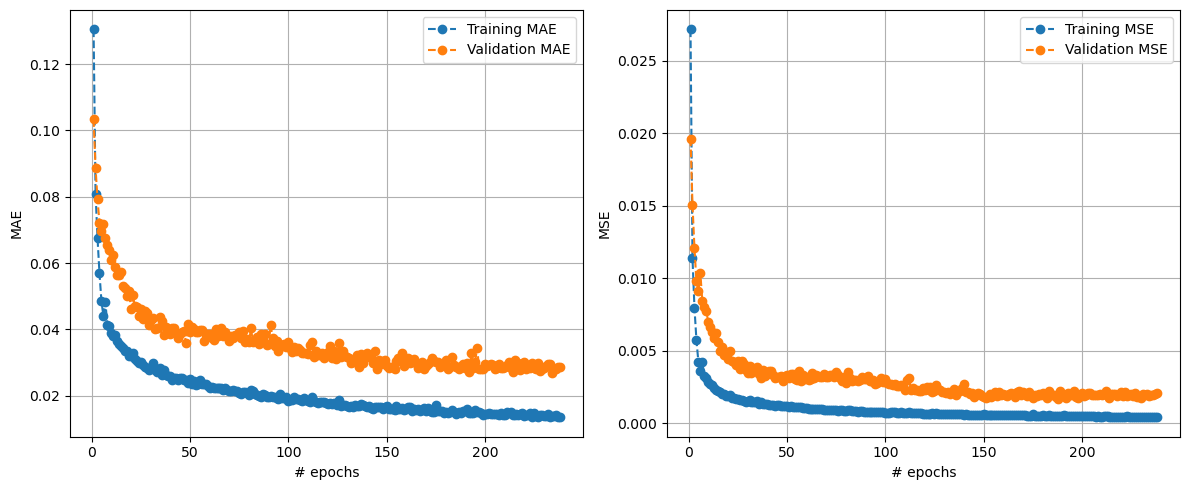

41/41 [==============================] - 1s 13ms/step - loss: 4.1428e-04 - mean_absolute_error: 0.0134 - val_loss: 0.0021 - val_mean_absolute_error: 0.0285


In [121]:
gru_model.fit(X_train_seq,
              y_train_seq,
              epochs=300,
              batch_size=72,
              validation_data=(X_val_seq, y_val_seq),
              callbacks=[
              PlotLearning(),
              EarlyStopping(monitor='val_loss', patience=50)])

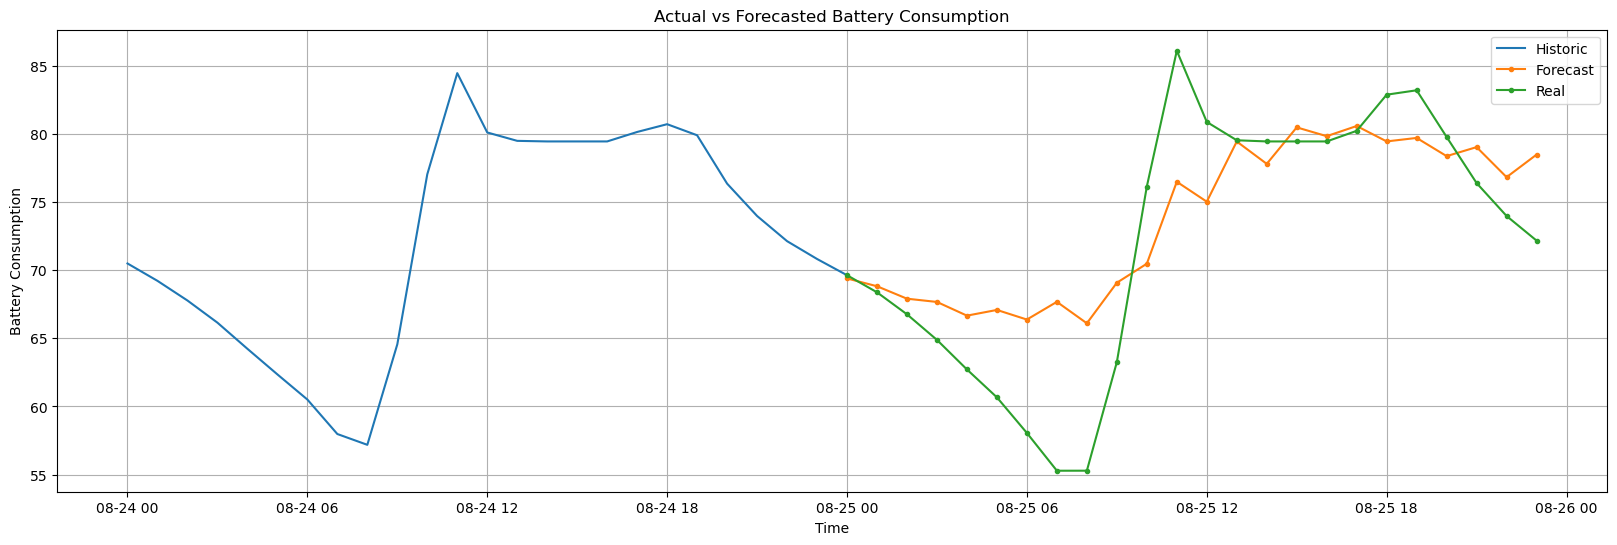

RMSE:  5.3353040442355235
MSE:   28.465469244435933
MAE:   4.044777158101401


(                 fecha  temperature  pressure  battery  air_humidity  \
 0  2018-08-24 00:00:00      22.0525  986.0375  70.4875       60.2500   
 1  2018-08-24 01:00:00      21.3825  986.2075  69.2125       61.7975   
 2  2018-08-24 02:00:00      24.1225  985.9675  67.7700       61.9850   
 3  2018-08-24 03:00:00      25.5925  985.7325  66.1450       60.5050   
 4  2018-08-24 04:00:00      24.4625  985.6400  64.2275       61.4950   
 5  2018-08-24 05:00:00      22.3000  985.4000  62.3500       63.9700   
 6  2018-08-24 06:00:00      20.7675  985.6425  60.5050       65.9150   
 7  2018-08-24 07:00:00      21.9075  986.1075  57.9750       66.3700   
 8  2018-08-24 08:00:00      25.2775  986.5650  57.1825       62.6175   
 9  2018-08-24 09:00:00      31.9325  986.8625  64.5550       53.4600   
 10 2018-08-24 10:00:00      37.0625  987.2950  77.0325       46.3225   
 11 2018-08-24 11:00:00      38.6950  987.4550  84.4500       38.5700   
 12 2018-08-24 12:00:00      40.2800  986.9375  80.

In [122]:
forecast_battery_consumption(test=test_dataset, seq_length=seq_length, forecast_steps=seq_length,
                             future_steps=future_steps, model=gru_model, scaler_x=scaler_x, scaler_y=scaler_y)

In [123]:
gru_model.save("modelo_GRU")
#tf.saved_model.save(gru_model, "modelo_GRU")

INFO:tensorflow:Assets written to: modelo_GRU/assets


INFO:tensorflow:Assets written to: modelo_GRU/assets


### Cuantización

In [124]:
#model_load = tf.saved_model.load("modelo_GRU")

In [195]:
# Select a few hundred samples randomly from the test dataset to calibrate the quantization:
def representative_data_gen():
    # Creamos un onjeto dataset de tensorflow
    data = tf.data.Dataset.from_tensor_slices(X_test_seq)
    #Iteramos sobre el dataset en lotes de tamaño 1, tomando los 100 primeros elementos de X_test
    for i_value in data.batch(1).take(100):
        # Convertimos a float32 los valores i_value
        i_value_f32 = tf.dtypes.cast(i_value, tf.float32)
        # Hacemos que la función sea un generador. En cada iteración se produce una lista que contiene el tensor i_value_f32
        yield [i_value_f32]

In [198]:
#i = 0
#for i_value in data.batch(1).take(100):
#        print(i_value)
#        i +=1
#        print(i)
#        i_value_f32 = tf.dtypes.cast(i_value, tf.float32)
#        print(f"trans f32: {i_value_f32}")

In [199]:
# Cargar el modelo guardado
TF_MODEL = "modelo_GRU"

In [209]:
#gru_conv = tf.lite.TFLiteConverter.from_saved_model(TF_MODEL)
gru_conv = tf.lite.TFLiteConverter.from_keras_model(gru_model)
gru_conv.optimizations = [tf.lite.Optimize.DEFAULT]
gru_conv.target_spec.supported_ops = [tf.lite.OpsSet.TFLITE_BUILTINS, tf.lite.OpsSet.SELECT_TF_OPS]
gru_conv.representative_dataset = tf.lite.RepresentativeDataset(representative_data_gen)
#gru_conv.target_spec.supported_ops = [tf.lite.OpsSet.TFLITE_BUILTINS_INT8]
gru_conv._experimental_lower_tensor_list_ops = False
gru_conv.inference_input_type = tf.int8
gru_conv.inference_output_type = tf.int8

In [210]:
tfl_gru_model = gru_conv.convert()

INFO:tensorflow:Assets written to: /tmp/tmpswnu_izg/assets


INFO:tensorflow:Assets written to: /tmp/tmpswnu_izg/assets
/home/felipe/miniconda3/envs/tensorflow2/lib/python3.9/site-packages/tensorflow/lite/python/convert.py:765: UserWarning: Statistics for quantized inputs were expected, but not specified; continuing anyway.
  warnings.warn("Statistics for quantized inputs were expected, but not "
2024-12-11 21:48:50.527211: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:362] Ignored output_format.
2024-12-11 21:48:50.527246: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:365] Ignored drop_control_dependency.
2024-12-11 21:48:50.527450: I tensorflow/cc/saved_model/reader.cc:45] Reading SavedModel from: /tmp/tmpswnu_izg
2024-12-11 21:48:50.534280: I tensorflow/cc/saved_model/reader.cc:89] Reading meta graph with tags { serve }
2024-12-11 21:48:50.534302: I tensorflow/cc/saved_model/reader.cc:130] Reading SavedModel debug info (if present) from: /tmp/tmpswnu_izg
2024-12-11 21:48:50.563549: I tensorflow/cc/s

In [211]:
# Guardar el modelo convertido a un archivo .tflite
with open("gru_model.tflite", "wb") as f:
    f.write(tfl_gru_model)

In [212]:
size_tfl_model = len(tfl_gru_model)
print(len(tfl_gru_model), "bytes")

21736 bytes


In [214]:
#!apt-get update && apt-get -qq install xxd --> da problemas con el sudo, mejor ejecutar desde la consola
!xxd -i "gru_model.tflite" > model_gru_lite.h
!sed -i 's/unsigned char/const unsigned char/g' model_gru_lite.h
!sed -i 's/const/alignas(8) const/g' model_gru_lite.h